# 联合纹理优化实验
## 目标：从球体逐步变形为带纹理的奶牛

In [63]:

%pip install --upgrade pip
%pip install fvcore iopath matplotlib ninja
%pip install 'git+https://gitee.com/hongwenzhang/pytorch3d.git' --no-build-isolation

Looking in indexes: https://mirrors.cloud.aliyuncs.com/pypi/simple
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://mirrors.cloud.aliyuncs.com/pypi/simple
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://mirrors.cloud.aliyuncs.com/pypi/simple
  Cloning https://gitee.com/hongwenzhang/pytorch3d.git to /tmp/pip-req-build-i_rxxo4v
  Running command git clone --filter=blob:none --quiet https://gitee.com/hongwenzhang/pytorch3d.git /tmp/pip-req-build-i_rxxo4v
  Resolved https://gitee.com/hongwenzhang/pytorch3d.git to commit b6a77ad7aaf41ed90fca80ce6a2bac3c462a7881
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.


In [64]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

import pytorch3d
from pytorch3d.io import load_obj, save_obj
from pytorch3d.structures import Meshes
from pytorch3d.utils import ico_sphere
from pytorch3d.loss import mesh_edge_loss, mesh_laplacian_smoothing, mesh_normal_consistency
from pytorch3d.renderer import (
    look_at_view_transform,
    FoVPerspectiveCameras,
    PointLights,
    RasterizationSettings,
    MeshRenderer,
    MeshRasterizer,
    SoftPhongShader,
    TexturesVertex
)

# 确认设备
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"当前运行设备: {device}")
print(f"PyTorch3D 版本: {pytorch3d.__version__}")

当前运行设备: cuda:0
PyTorch3D 版本: 0.7.9


## 1. 加载目标奶牛模型并创建纹理

In [65]:
# 加载目标模型
obj_path = "cow.obj"
if not os.path.exists(obj_path):
    raise FileNotFoundError("未找到 cow.obj，请确保代码文件与 obj 文件在同一目录下！")

# 准备目标数据与归一化处理
verts, faces, _ = load_obj(obj_path)
faces_idx = faces.verts_idx.to(device)
verts = verts.to(device)
verts = (verts - verts.mean(0)) / max(verts.abs().max(0)[0])

# 为目标模型创建更真实的奶牛纹理
def create_cow_texture(verts, device):
    """创建奶牛纹理：白色基础 + 黑色/棕色斑点 + 粉色鼻子 + 深色眼睛"""
    num_verts = verts.shape[0]
    rgb = torch.full((1, num_verts, 3), 0.95, device=device)  # 白色基础
    
    # 计算顶点到中心的距离，用于生成斑点
    verts_np = verts.cpu().numpy()
    
    # 添加黑色斑点
    for i in range(num_verts):
        x, y, z = verts_np[i]
        
        # 随机生成斑点模式
        if np.sin(x * 5) * np.cos(y * 5) > 0.3 or np.sin(z * 7) > 0.5:
            rgb[0, i] = torch.tensor([0.2, 0.2, 0.25], device=device)  # 深色斑点
        elif np.sin(x * 3 + y * 2) > 0.6:
            rgb[0, i] = torch.tensor([0.5, 0.35, 0.25], device=device)  # 棕色斑点
    
    # 添加粉色鼻子区域（前部）
    nose_mask = (verts_np[:, 2] < -0.6) & (np.abs(verts_np[:, 0]) < 0.3)
    rgb[0, nose_mask] = torch.tensor([0.95, 0.7, 0.65], device=device)
    
    # 添加深色眼睛区域
    eye_mask1 = (verts_np[:, 2] < -0.3) & (verts_np[:, 2] > -0.7) & \
                 (verts_np[:, 1] > 0.2) & (np.abs(verts_np[:, 0]) > 0.2)
    eye_mask2 = (verts_np[:, 2] < -0.3) & (verts_np[:, 2] > -0.7) & \
                 (verts_np[:, 1] > 0.2) & (np.abs(verts_np[:, 0]) > 0.2)
    rgb[0, eye_mask1 | eye_mask2] = torch.tensor([0.1, 0.08, 0.1], device=device)
    
    return rgb

target_rgb = create_cow_texture(verts, device)
target_mesh = Meshes(
    verts=[verts], 
    faces=[faces_idx], 
    textures=TexturesVertex(verts_features=target_rgb)
)

print(f"目标模型加载完成，顶点数: {verts.shape[0]}")

目标模型加载完成，顶点数: 2930


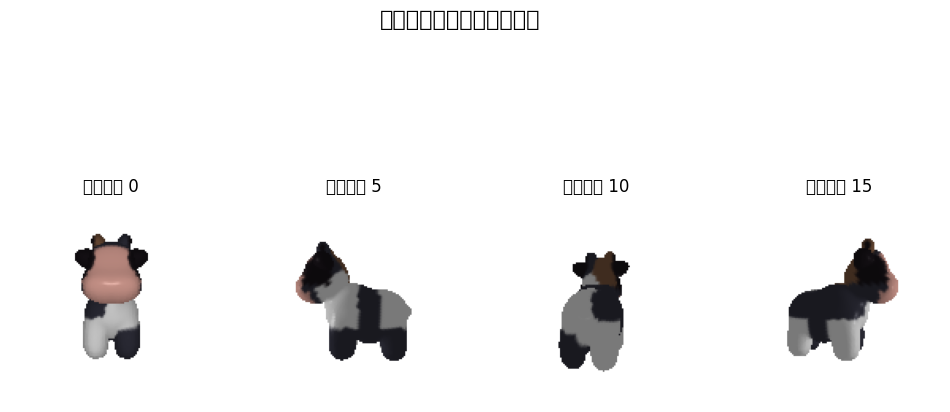

In [66]:
# 渲染管线与摄像机配置
num_views = 20
elev = torch.zeros(num_views)
azim = torch.linspace(-180, 180, num_views)

R, T = look_at_view_transform(dist=2.7, elev=elev, azim=azim)
cameras = FoVPerspectiveCameras(device=device, R=R, T=T)

# 灯光设置
lights = PointLights(device=device, location=[[0.0, 0.0, -3.0]])

# 渲染设置
sigma = 1e-4
raster_settings = RasterizationSettings(
    image_size=128,
    blur_radius=np.log(1. / 1e-4 - 1.)*sigma,
    faces_per_pixel=50,
    perspective_correct=False,
)

# 创建渲染器
renderer = MeshRenderer(
    rasterizer=MeshRasterizer(
        cameras=cameras,
        raster_settings=raster_settings
    ),
    shader=SoftPhongShader(device=device, cameras=cameras, lights=lights)
)

# 生成目标图像（RGB + 剪影）
target_images = renderer(target_mesh.extend(num_views), cameras=cameras, lights=lights)
target_rgb_images = [target_images[i, ..., :3] for i in range(num_views)]
target_silhouette = [target_images[i, ..., 3] for i in range(num_views)]

# 可视化目标模型
plt.figure(figsize=(12, 6))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(target_rgb_images[i*5].cpu().numpy())
    plt.title(f"目标视角 {i*5}")
    plt.axis('off')
plt.suptitle("目标奶牛模型（不同视角）", fontsize=16)
plt.show()

## 2. 初始化优化参数（从球体开始）

中间模型将保存在目录: ./sphere_to_cow/


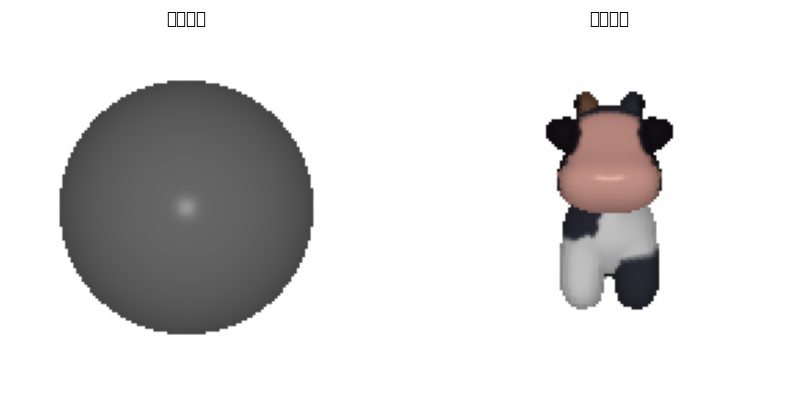

In [67]:
# 从球体开始
src_mesh = ico_sphere(4, device)

# 顶点偏移（用于形状优化）
deform_verts = torch.zeros_like(src_mesh.verts_packed(), requires_grad=True)

# 顶点颜色（用于纹理优化）
verts_shape = src_mesh.verts_packed().shape
verts_rgb = torch.full([1, verts_shape[0], 3], 0.5, device=device, requires_grad=True)

# 优化器
optimizer = torch.optim.SGD([deform_verts, verts_rgb], lr=1.0, momentum=0.9)

# 创建保存中间结果的文件夹
output_dir = "sphere_to_cow"
os.makedirs(output_dir, exist_ok=True)
print(f"中间模型将保存在目录: ./{output_dir}/")

# 可视化初始球体
initial_mesh = src_mesh.offset_verts(deform_verts.detach())
initial_mesh.textures = TexturesVertex(verts_features=verts_rgb.detach())
initial_camera = FoVPerspectiveCameras(device=device, R=R[None, 0, ...], T=T[None, 0, ...])
initial_image = renderer(initial_mesh, cameras=initial_camera, lights=lights)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(initial_image[0, ..., :3].cpu().numpy())
plt.title("初始球体")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(target_rgb_images[0].cpu().numpy())
plt.title("目标奶牛")
plt.axis('off')
plt.show()

## 3. 球变牛：联合优化循环

In [68]:
# 优化参数
epochs = 3000
num_views_per_iter = 2  # 每次迭代随机选2个视图来优化
plot_period = 300  # 每300轮可视化一次

# 损失权重
loss_weights = {
    "rgb": 1.5,
    "silhouette": 1.0,
    "edge": 0.1,
    "laplacian": 1.0,
    "normal": 0.01
}

# 记录损失和中间可视化
loss_history = {k: [] for k in loss_weights.keys()}
visualization_steps = []  # 保存可视化的步数
visualization_images = []  # 保存可视化图像

迭代步数: 2999/3000, 总损失: 0.0109
  edge: 0.0028
  laplacian: 0.0039
  normal: 0.0250
  rgb: 0.0033
  silhouette: 0.0016
已保存: sphere_to_cow/mesh_epoch_2999.obj


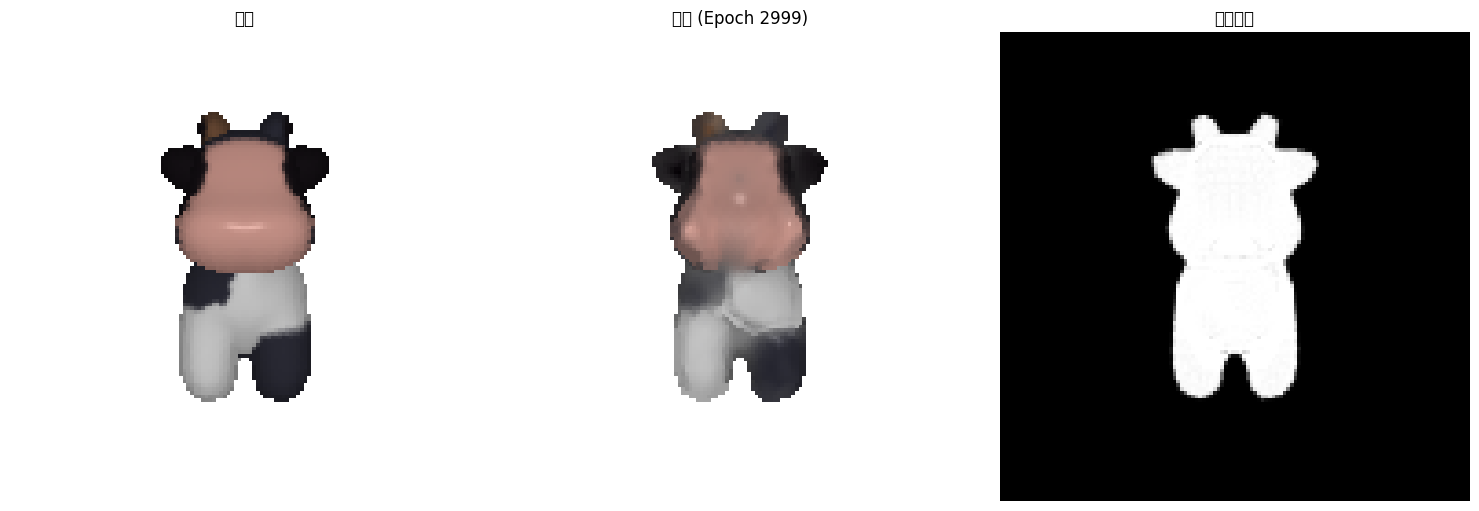

✅ 球变牛优化完成！


In [69]:
for i in range(epochs):
    optimizer.zero_grad()
    
    # 形变网格
    new_src_mesh = src_mesh.offset_verts(deform_verts)
    
    # 添加纹理
    new_src_mesh.textures = TexturesVertex(verts_features=verts_rgb)
    
    # 计算形状正则化损失
    loss = {}
    loss["edge"] = mesh_edge_loss(new_src_mesh)
    loss["laplacian"] = mesh_laplacian_smoothing(new_src_mesh, method="uniform")
    loss["normal"] = mesh_normal_consistency(new_src_mesh)
    
    # 随机选择视图
    loss["rgb"] = torch.tensor(0.0, device=device)
    loss["silhouette"] = torch.tensor(0.0, device=device)
    
    for j in np.random.permutation(num_views)[:num_views_per_iter]:
        # 渲染当前视图
        camera_j = FoVPerspectiveCameras(device=device, R=R[None, j, ...], T=T[None, j, ...])
        images_predicted = renderer(new_src_mesh, cameras=camera_j, lights=lights)
        
        # 计算RGB损失
        predicted_rgb = images_predicted[..., :3]
        loss["rgb"] += ((predicted_rgb - target_rgb_images[j]) ** 2).mean() / num_views_per_iter
        
        # 计算剪影损失
        predicted_silhouette = images_predicted[..., 3]
        loss["silhouette"] += ((predicted_silhouette - target_silhouette[j]) ** 2).mean() / num_views_per_iter
    
    # 总损失
    total_loss = sum(loss[k] * loss_weights[k] for k in loss_weights.keys())
    
    # 反向传播
    total_loss.backward()
    optimizer.step()
    
    # 记录损失
    for k in loss_history.keys():
        loss_history[k].append(loss[k].item())
    
    # 可视化与保存
    if i % plot_period == 0 or i == epochs - 1:
        clear_output(wait=True)
        print(f"迭代步数: {i}/{epochs}, 总损失: {total_loss.item():.4f}")
        for k in loss.keys():
            print(f"  {k}: {loss[k].item():.4f}")
        
        # 保存模型
        current_verts = new_src_mesh.verts_list()[0]
        current_faces = new_src_mesh.faces_list()[0]
        save_path = os.path.join(output_dir, f"mesh_epoch_{i:04d}.obj")
        save_obj(save_path, current_verts, current_faces)
        print(f"已保存: {save_path}")
        
        # 可视化对比
        view_idx = 0  # 固定视角以便对比
        camera_fixed = FoVPerspectiveCameras(device=device, R=R[None, view_idx, ...], T=T[None, view_idx, ...])
        
        with torch.no_grad():
            pred_img = renderer(new_src_mesh, cameras=camera_fixed, lights=lights)
        
        # 保存可视化图像用于后续展示
        visualization_steps.append(i)
        visualization_images.append(pred_img[0, ..., :3].cpu().numpy())
        
        # 实时展示
        plt.figure(figsize=(15, 5))
        
        plt.subplot(1, 3, 1)
        plt.imshow(target_rgb_images[view_idx].cpu().numpy())
        plt.title("目标")
        plt.axis('off')
        
        plt.subplot(1, 3, 2)
        plt.imshow(pred_img[0, ..., :3].cpu().numpy())
        plt.title(f"当前 (Epoch {i})")
        plt.axis('off')
        
        plt.subplot(1, 3, 3)
        plt.imshow(target_silhouette[view_idx].cpu().numpy(), cmap='gray')
        plt.imshow(pred_img[0, ..., 3].cpu().numpy(), cmap='gray', alpha=0.5)
        plt.title("剪影对比")
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()

print("✅ 球变牛优化完成！")

## 4. 变形过程

/tmp/ipykernel_1026/219233804.py:12: UserWarning: Glyph 128002 (\N{OX}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1026/219233804.py:12: UserWarning: Glyph 29699 (\N{CJK UNIFIED IDEOGRAPH-7403}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1026/219233804.py:12: UserWarning: Glyph 21464 (\N{CJK UNIFIED IDEOGRAPH-53D8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1026/219233804.py:12: UserWarning: Glyph 29275 (\N{CJK UNIFIED IDEOGRAPH-725B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1026/219233804.py:12: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1026/219233804.py:12: UserWarning: Glyph 36807 (\N{CJK UNIFIED IDEOGRAPH-8FC7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1026/219233804.py:12: UserWarning: Glyph 31243 (\N{CJK UNIFIED IDEOGRAPH-7A0B}) missing from font(s) DejaVu 

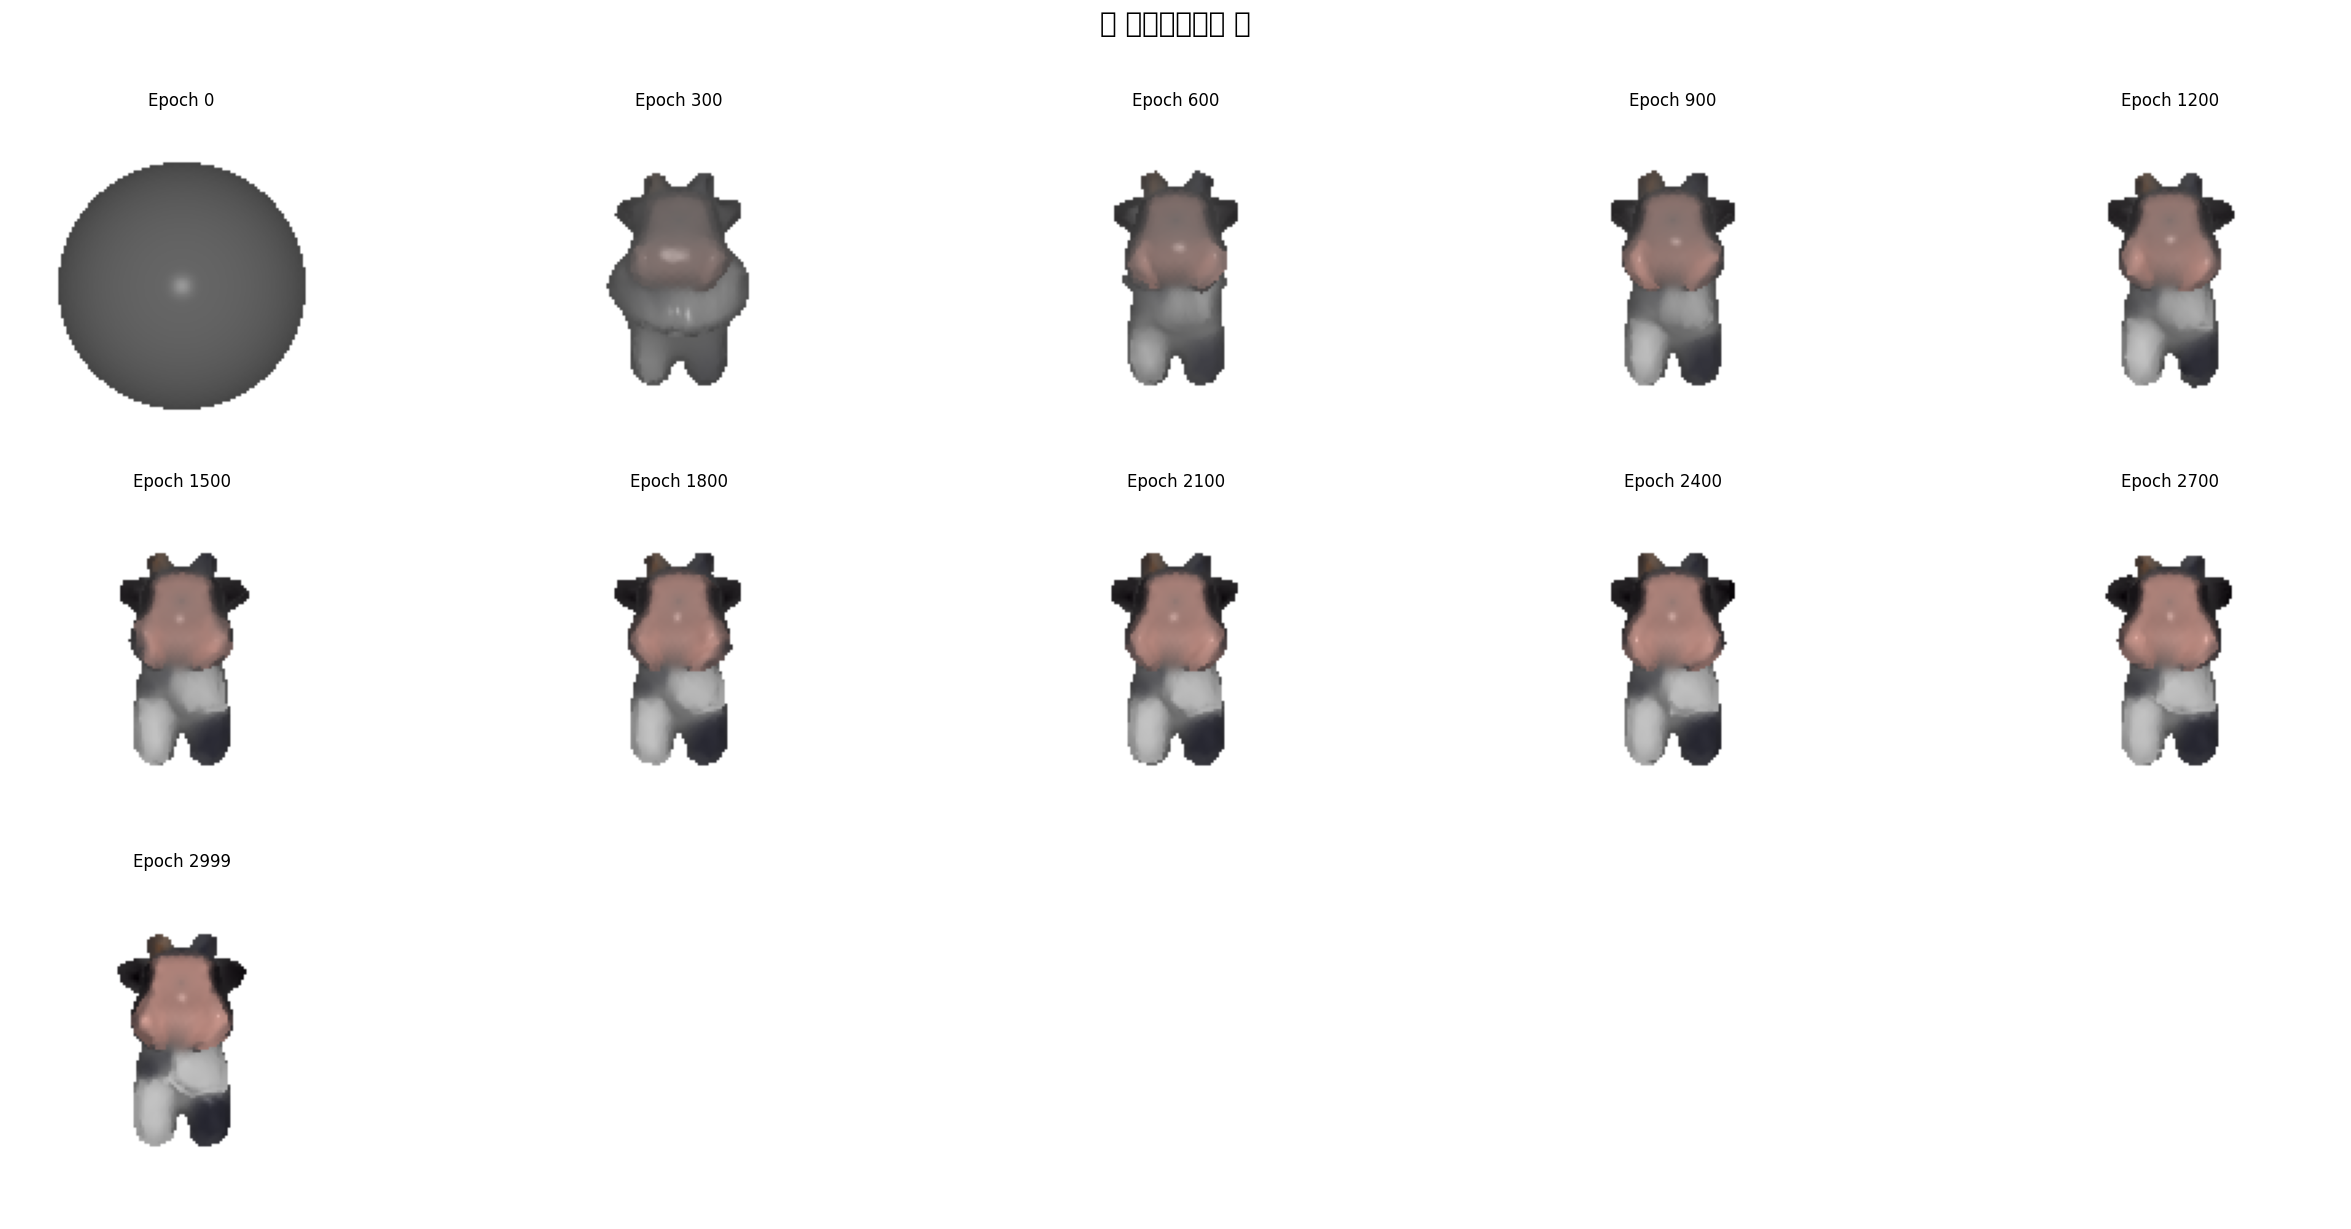

In [70]:
# 展示完整的变形过程
n_cols = min(5, len(visualization_images))
n_rows = (len(visualization_images) + n_cols - 1) // n_cols

plt.figure(figsize=(5*n_cols, 4*n_rows))
for i, (step, img) in enumerate(zip(visualization_steps, visualization_images)):
    plt.subplot(n_rows, n_cols, i+1)
    plt.imshow(img)
    plt.title(f"Epoch {step}")
    plt.axis('off')
plt.suptitle("🐂 球变牛的过程 🐂", fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

## 5. 最终结果多视角展示

/tmp/ipykernel_1026/2654107681.py:28: UserWarning: Glyph 30446 (\N{CJK UNIFIED IDEOGRAPH-76EE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1026/2654107681.py:28: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1026/2654107681.py:28: UserWarning: Glyph 35270 (\N{CJK UNIFIED IDEOGRAPH-89C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1026/2654107681.py:28: UserWarning: Glyph 35282 (\N{CJK UNIFIED IDEOGRAPH-89D2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1026/2654107681.py:28: UserWarning: Glyph 20248 (\N{CJK UNIFIED IDEOGRAPH-4F18}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1026/2654107681.py:28: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1026/2654107681.py:28: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}

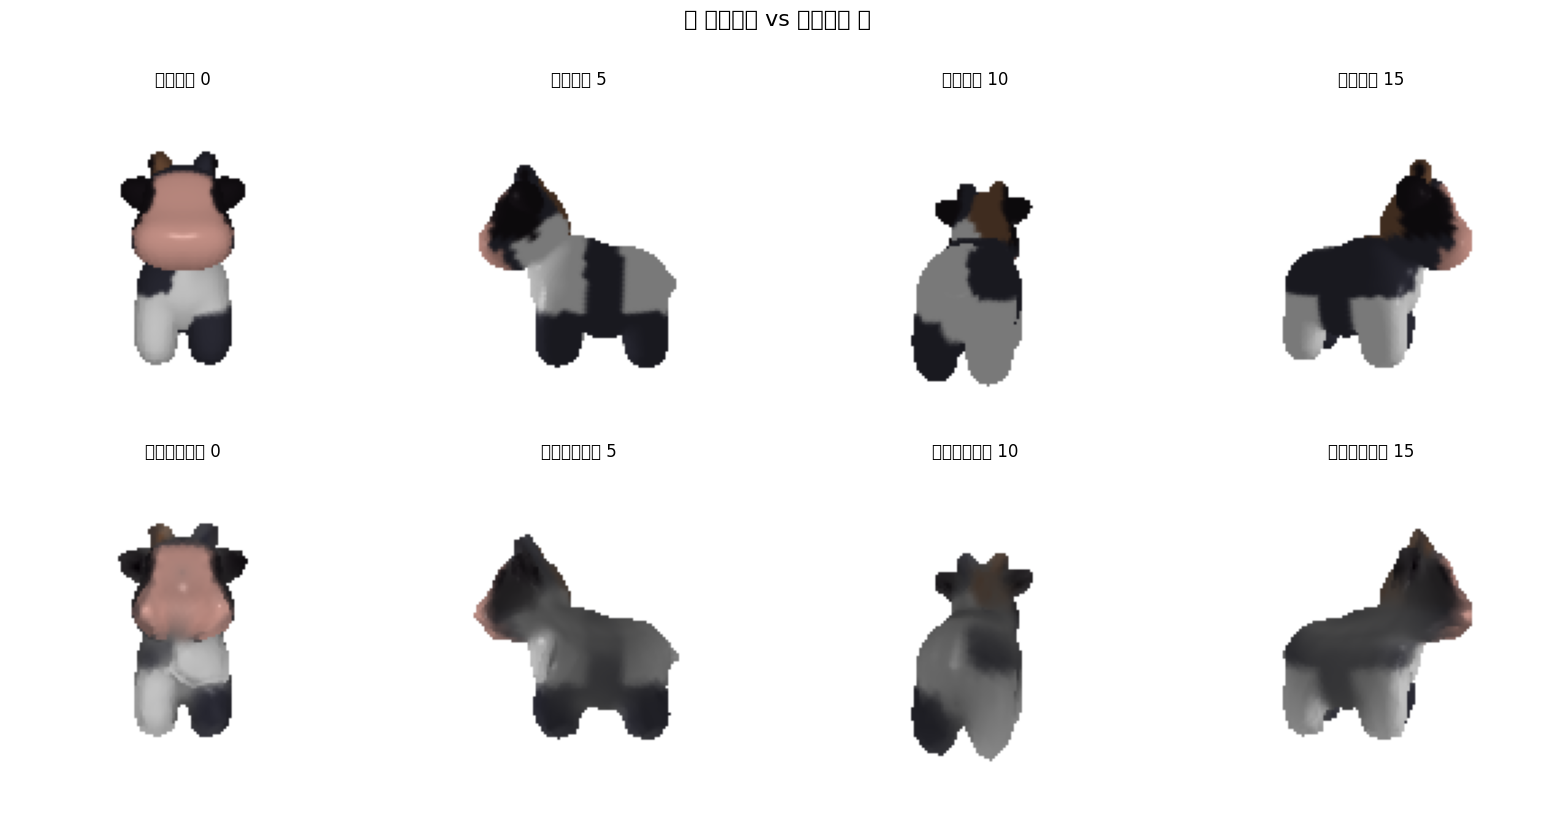

In [71]:
# 从多个角度展示最终结果
final_mesh = src_mesh.offset_verts(deform_verts.detach())
final_mesh.textures = TexturesVertex(verts_features=verts_rgb.detach())

# 渲染几个不同视角
view_indices = [0, 5, 10, 15]

plt.figure(figsize=(16, 8))

for idx, view_idx in enumerate(view_indices):
    camera = FoVPerspectiveCameras(device=device, R=R[None, view_idx, ...], T=T[None, view_idx, ...])
    with torch.no_grad():
        pred_img = renderer(final_mesh, cameras=camera, lights=lights)
    
    # 目标图像
    plt.subplot(2, 4, idx+1)
    plt.imshow(target_rgb_images[view_idx].cpu().numpy())
    plt.title(f"目标视角 {view_idx}")
    plt.axis('off')
    
    # 预测图像
    plt.subplot(2, 4, idx+5)
    plt.imshow(pred_img[0, ..., :3].cpu().numpy())
    plt.title(f"优化结果视角 {view_idx}")
    plt.axis('off')

plt.suptitle("🎯 目标模型 vs 优化结果 🎯", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()